# Case Study: ACS Employment

In [10]:
import sys
sys.path.append("..")

import torch
from tqdm.auto import tqdm
from copy import deepcopy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import networkx as nx
from explainerpfn.base import ExplainerPFN
from mlresearch.utils import set_matplotlib_style

set_matplotlib_style(use_latex=False, font_size=18, **{"font.family":"serif"})

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "../../explainerpfn_model_NOV_15.ckp"

No GPU available. Training will run on CPU.


In [2]:
from folktables import ACSDataSource, ACSPublicCoverage

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["AL"], download=True)
df, y, group = ACSPublicCoverage.df_to_pandas(acs_data)

## Getting model explanations

In [3]:
df = df[["AGEP", "SCHL", "PINCP", "SEX"]]

X_train, X_test, y_train, y_test = train_test_split(
    df, y.values.squeeze(), test_size=2000, random_state=42
)
X_train, _, y_train, _ = train_test_split(
    X_train, y_train, train_size=2000, random_state=42
)

In [4]:
model_search = GridSearchCV(
    estimator=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPClassifier(max_iter=2000, random_state=42)),
        ]
    ),
    param_grid={
        "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "mlp__activation": ["relu", "tanh"],
        "mlp__alpha": [0.0001, 0.001, 0.01],
    },
    cv=3,
    n_jobs=16,
    scoring="f1_macro",
    verbose=1
)
model_search.fit(X_train, y_train)
clf = model_search.best_estimator_
print("Best parameters found: ", model_search.best_params_)
print("Test set F1 macro: ", model_search.best_score_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/joaofonseca/miniconda3/envs/tfm/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't conv

Best parameters found:  {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (50, 50)}
Test set F1 macro:  0.6518312318898114


In [5]:
# clf = Pipeline(
#     [
#         ("scaler", StandardScaler()),
#         ("mlp", MLPClassifier(hidden_layer_sizes=(50,), activation="relu", alpha=0.0001, random_state=42)),
#     ]
# )
# clf.fit(X_train, y_train)
y_test_scores = clf.predict_proba(X_test)[:, -1]
y_train_scores = clf.predict_proba(X_train)[:, -1]

In [6]:
shap_explanations = shap.Explainer(clf.predict_proba, X_train)
shap_values = shap_explanations(X_test).values[:, :, -1]

In [7]:
import pandas as pd
import numpy as np

xai = ExplainerPFN(n_estimators=4, model_path=model_path, random_state=42, device=device)
xai.fit(pd.concat([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))

exp_pfn_values = xai.predict(X_test.values, y_test_scores)

In [8]:
exp_corr = exp_pfn_values.copy()
exp_corr = xai.apply_correction(y_test_scores, exp_corr, kind=["statistical", "additive"])

In [93]:
# Correlation between SHAP and ExplainerPFN values
np.corrcoef(shap_values.reshape(-1), exp_corr.reshape(-1))

array([[1.        , 0.31882039],
       [0.31882039, 1.        ]])

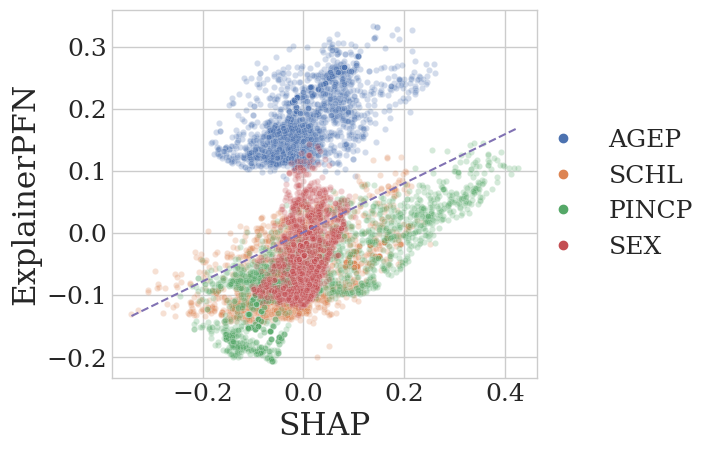

In [91]:
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7.5, 5))

reg = LinearRegression().fit(shap_values.reshape(-1, 1), exp_corr.reshape(-1, 1))
x = np.linspace(shap_values.min(), shap_values.max(), 100).reshape(-1, 1)
lin_values = reg.predict(x)

for i, col in enumerate(X_test.columns):
    sns.scatterplot(x=shap_values[:, i], y=exp_corr[:, i], label=col, s=20, alpha=0.25, ax=ax)

# ax = plt.gca()
orig_handles, orig_labels = ax.get_legend_handles_labels()

opaque_handles = [
    Line2D([0], [0], marker='o', color=h.get_facecolor()[0], linestyle='',
           markersize=6, alpha=1)
    for h in orig_handles
]

sns.lineplot(x=x.flatten(), y=lin_values.flatten(), color='C4', linestyle='--', ax=ax)

ax.legend(
    opaque_handles,
    orig_labels,
    title=None,
    bbox_to_anchor=(0.95, 0.5),
    loc='center left',
    ncol=1,  # len(orig_labels),
)

plt.xlabel("SHAP")
plt.ylabel("ExplainerPFN")
plt.tight_layout()
plt.savefig("case_study_shap_vs_explainerpfn.pdf")
plt.show()

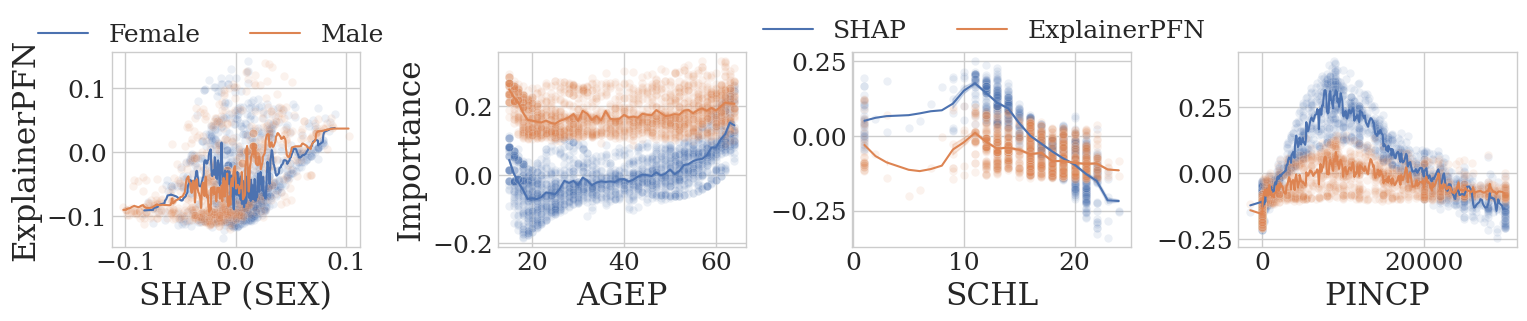

In [58]:
from scipy.ndimage import gaussian_filter1d

sigma = 2.0

fig, axs = plt.subplots(1, len(X_test.columns), figsize=(4 * len(X_test.columns), 4))
# plt.subplots_adjust(hspace=0.4)


# Plot variable Sex separately
col_name = "SEX" 
values_mapper = {
    1: "Male",
    2: "Female"
}
col_idx = X_test.columns.tolist().index(col_name)
unique_values = X_test[col_name].unique()
for unique_val in unique_values:
    mask = X_test[col_name] == unique_val
    x=shap_values[:, col_idx][mask]
    y=exp_corr[:, col_idx][mask]

    sns.scatterplot(x=x, y=y, alpha=0.1, ax=axs[0])

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    y_smooth = gaussian_filter1d(y_sorted, sigma=sigma*2)

    sns.lineplot(x=x_sorted, y=y_smooth, ax=axs[0], label=values_mapper[int(unique_val)])

axs[0].legend(title=col_name)
axs[0].set_xlabel(f"SHAP ({col_name})")
axs[0].set_ylabel("ExplainerPFN")

handles0, labels0 = axs[0].get_legend_handles_labels()
axs[0].legend(handles0, labels0,
              # title=col_name,
              bbox_to_anchor=(0.4, 1.26),   # above subplot 1
              loc='upper center',
              ncol=len(labels0))


# Plot remaining variables
shared_handles = []
shared_labels = []
for k, col_name in enumerate(X_test.columns.drop("SEX"), start=1):
    col_idx = X_test.columns.tolist().index(col_name)

    sns.scatterplot(x=X_test[col_name], y=shap_values[:, col_idx], alpha=0.1, ax=axs[k])
    sns.scatterplot(x=X_test[col_name], y=exp_corr[:, col_idx], alpha=0.1, ax=axs[k])

    for label, contribs_ in zip(["SHAP", "ExplainerPFN"], [shap_values, exp_corr]):
        order = np.argsort(X_test[col_name].values)
        x_sorted = X_test[col_name].values[order]
        y_sorted = contribs_[:, col_idx][order]
        y_smooth = gaussian_filter1d(y_sorted, sigma=sigma)

        sns.lineplot(x=x_sorted, y=y_smooth, ax=axs[k], label=label)

    if axs[k].get_legend() is not None:
        axs[k].get_legend().remove()

    # store handles for shared legend
    h, l = axs[k].get_legend_handles_labels()
    shared_handles.extend(h)
    shared_labels.extend(l)

axs[1].set_ylabel("Importance")

# Remove duplicates for the shared legend (SHAP, ExplainerPFN)
unique_pairs = dict(zip(shared_labels, shared_handles))
shared_handles = list(unique_pairs.values())
shared_labels = list(unique_pairs.keys())

fig.legend(shared_handles, shared_labels,
           bbox_to_anchor=(0.63, .87),  # centered above last 3 subplots
           loc='upper center',
           ncol=len(shared_labels))

plt.tight_layout()

for i in range(1, X_test.shape[1]-1):
    pos1 = axs[i].get_position()  # Bbox(x0, y0, x1, y1)
    pos2 = axs[i+1].get_position()

    # Shift ax2 to the right to increase the gap between ax1 and ax2
    new_pos2 = [pos2.x0 - 0.02, pos2.y0, pos2.width + 0.02, pos2.height]
    axs[i+1].set_position(new_pos2)

plt.savefig("case_study_featurewise_comparison.pdf")
plt.show()

## DAG Reconstruction

In [528]:
def get_all_explanations(xai_model, df):
    explanations = {}
    for target_col in tqdm(df.columns): 
        X = df.drop(columns=[target_col]).values
        y = df[target_col].values

        xai = deepcopy(xai_model)
        xai.fit(X, y)
        exp_values = xai.predict(X, y)
        exp_values = xai.apply_correction(y, exp_values - exp_values.mean(axis=0), kind=["statistical", "additive"])
        explanations[target_col] = pd.DataFrame(exp_values, columns=df.drop(columns=[target_col]).columns)
    return explanations

In [529]:
def make_dag_from_explanations(explanations, threshold=75):
    G = nx.DiGraph()
    edges = []
    for target in explanations:
        exp_df = explanations[target].abs().mean()
        edges.extend([{"source": source, "target": target, "weight": weight} for source, weight in exp_df.items()])

    # Filter edges by threshold
    all_weights = [edge["weight"] for edge in edges]
    threshold = np.percentile(all_weights, threshold)
    edges = [edge for edge in edges if edge["weight"] > threshold]
    for edge in edges:
        G.add_edge(edge["source"], edge["target"], weight=edge["weight"])
    return G

In [530]:
def plot_dag(G, colors=None):
    colors = colors if colors is not None else "#A0CBE2"
    plt.figure(figsize=(4, 4))
    pos = nx.shell_layout(G)
    nx.draw(
        G, pos, with_labels=True, arrows=True, node_size=700, node_color=colors
    )
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)
    plt.show()

In [535]:
df_dag = X_test.copy()
df_dag["PCOV"] = y_test.astype(int)

xai_model = ExplainerPFN(model_path=model_path, random_state=42, device=device)
explanations = get_all_explanations(xai_model, df_dag)

  0%|          | 0/5 [00:00<?, ?it/s]

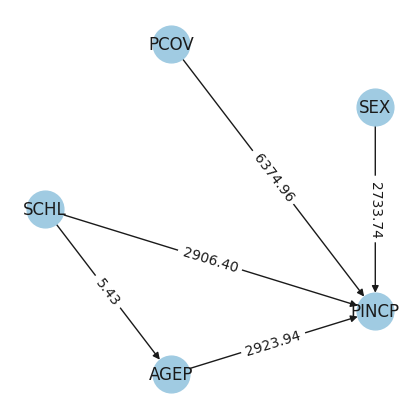

In [544]:
# Plot explanation graph
G_exp = make_dag_from_explanations(explanations, threshold=75)
plot_dag(G_exp)

In [ ]:
# Tasks:
# 1. Recover causal structure
# 2. Help determine which ML model are more appropriate for a given dataset, based on how well they align with Shapley value expectations
# 3. Are faithful to regular feature importance measures
# 4. Compare different observations explanations
